# HGFND — Verification Threshold Sweep  v2

**New in v2 vs v1:**
- **7 seeds** (up from 3) → SE ≈ 0.012, effects ≥0.02 acc are now interpretable
- **≥7% threshold** added to the sweep
- **Ablation at >0% and ≥5%**: above-edge-only vs below-edge-only — isolates which half drives accuracy

| Group | Config | Verification hyperedge rule |
|---|---|---|
| Sweep | Baseline | No verification edge |
| Sweep | +Both >0% | Both edges, any verified user (current) |
| Sweep | +Both ≥1% | Both edges, ≥1% verified |
| Sweep | +Both ≥3% | Both edges, ≥3% verified |
| Sweep | +Both ≥5% | Both edges, ≥5% verified — best in v1 |
| Sweep | +Both ≥7% | Both edges, ≥7% verified — new |
| Ablation >0% | +Above-only >0% | Only the "above" edge (183 items, 64% real) |
| Ablation >0% | +Below-only >0% | Only the "below" edge (131 items, 100% fake) |
| Ablation ≥5% | +Above-only ≥5% | Only the "above" edge (81 items, 89% real) |
| Ablation ≥5% | +Below-only ≥5% | Only the "below" edge (233 items, 64% fake) |

Split: **20% train / 10% val / 70% test**. Best-val-acc checkpoint → test metrics.  
**Instructions**: Set runtime to GPU → Run all cells sequentially (~90–160 min on T4).

## Phase 1 — Environment Setup

In [ ]:
import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"CUDA v  : {torch.version.cuda}")
else:
    print("WARNING: No GPU detected — training will be slow.")

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4
CUDA v  : 12.8


In [ ]:
import torch, subprocess, sys

TORCH_VERSION = torch.__version__.split('+')[0]
CUDA_VERSION  = torch.version.cuda.replace('.', '') if torch.version.cuda else 'cpu'
print(f'Installing PyG for PyTorch {TORCH_VERSION} CUDA {CUDA_VERSION}')

get_ipython().system('pip install -q torch_geometric gdown')

for pkg in ['torch_scatter', 'torch_sparse', 'torch_cluster']:
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q', pkg,
         '-f', f'https://data.pyg.org/whl/torch-{TORCH_VERSION}+cu{CUDA_VERSION}.html'],
        capture_output=True, text=True)
    print(f'  {"✓" if r.returncode == 0 else "⚠"} {pkg}')

Installing PyG for PyTorch 2.11.0 CUDA 128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.6 MB/s eta 0:00:00
  ✓ torch_scatter
  ✓ torch_sparse
  ✓ torch_cluster


In [ ]:
import os
if not os.path.exists('IEEEBigdata22_HGFND'):
    get_ipython().system('git clone https://github.com/ujeong1/IEEEBigdata22_HGFND.git')
    print('Repository cloned.')
else:
    print('Repo already exists, skipping clone.')
get_ipython().run_line_magic('cd', 'IEEEBigdata22_HGFND')

Cloning into 'IEEEBigdata22_HGFND'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 74 (delta 26), reused 22 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 13.69 MiB | 6.87 MiB/s, done.
Resolving deltas: 100% (26/26), done.
Repository cloned.
/content/IEEEBigdata22_HGFND


In [ ]:
get_ipython().system('pip install -q -r requirements.txt')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 47.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
import sys, types, torch

try:
    import torch_sparse
    print('torch_sparse available')
except ModuleNotFoundError:
    from torch_geometric.utils import coalesce as _pyg_coalesce
    torch_sparse = types.ModuleType('torch_sparse')
    def _coalesce(edge_index, edge_attr, ns, nd):
        return _pyg_coalesce(edge_index, edge_attr, max(ns, nd))
    torch_sparse.coalesce = _coalesce
    sys.modules['torch_sparse'] = torch_sparse
    print('Using PyG native coalesce (torch_sparse not installed)')

_orig_load = torch.load
def _patched_load(*a, **kw):
    kw.setdefault('weights_only', False)
    return _orig_load(*a, **kw)
torch.load = _patched_load
print('torch.load patched for PyTorch 2.6+ compatibility')

torch_sparse available
torch.load patched for PyTorch 2.6+ compatibility


In [ ]:
import gdown, zipfile, os

GDRIVE_FOLDER_ID = '1OslTX91kLEYIi2WBnwuFtXsVz5SS_XeR'
pol_ready = os.path.exists('data/politifact/raw/node_graph_id.npy')

if not pol_ready:
    if not os.path.exists('data_download/politifact.zip'):
        print('Downloading PolitiFact dataset from Google Drive...')
        gdown.download_folder(id=GDRIVE_FOLDER_ID, output='data_download', quiet=False)
    os.makedirs('data/politifact/raw', exist_ok=True)
    with zipfile.ZipFile('data_download/politifact.zip', 'r') as z:
        z.extractall('data/politifact/raw/')
    print('✓ PolitiFact extracted')
else:
    print('PolitiFact already present, skipping download.')
print('Files:', os.listdir('data/politifact/raw/'))

Retrieving folder contents


Processing file 1DkMAzC7XUUciAxsSujRJt3sq1MqaVI3g gossipcop.zip
Processing file 1toou2GO0agoY_OS54LaCWEECQfe93nuq politifact.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1DkMAzC7XUUciAxsSujRJt3sq1MqaVI3g
From (redirected): https://drive.google.com/uc?id=1DkMAzC7XUUciAxsSujRJt3sq1MqaVI3g&confirm=t&uuid=b1825143-d72d-4548-a742-e1b95fb7b9bd
To: /content/IEEEBigdata22_HGFND/data_download/gossipcop.zip
100%|██████████| 1.40G/1.40G [00:23<00:00, 59.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1toou2GO0agoY_OS54LaCWEECQfe93nuq
From (redirected): https://drive.google.com/uc?id=1toou2GO0agoY_OS54LaCWEECQfe93nuq&confirm=t&uuid=aad078d2-203f-4de5-a715-e15580278478
To: /content/IEEEBigdata22_HGFND/data_download/politifact.zip
100%|██████████| 198M/198M [00:04<00:00, 42.8MB/s]
Download completed


✓ PolitiFact extracted
Files: ['train_idx.npy', 'test_idx.npy', 'graph_labels.npy', 'new_profile_feature.npz', 'new_spacy_feature.npz', 'new_content_feature.npz', 'node_graph_id.npy', 'new_bert_feature.npz', 'A.txt', 'val_idx.npy']


## Phase 2 — Configuration

Edit `SEEDS`, `EPOCHS`, or `CONFIGS` here. Re-run from this cell onward if you change anything.

In [ ]:
import argparse

DATASET = 'politifact'
EPOCHS  = 200

# 7 seeds: SE ≈ std/√7 ≈ 0.012 — effects ≥ 0.02 acc are now interpretable
SEEDS = [42, 2026, 33, 123, 456, 789, 1000]

# ── 10 configurations ─────────────────────────────────────────────────────────
# edge_mode: 'none' | 'both' | 'above_only' | 'below_only'
# threshold: None (no edge) | 0.00 (strict >0 rule) | 0.01/0.03/0.05/0.07 (>=)
# Color encodes threshold; line-style (ls) encodes edge_mode for the plots.
CONFIGS = [
    # ── Threshold sweep (both edges) ─────────────────────────────────────────
    {'label': 'Baseline',        'threshold': None, 'edge_mode': 'none',       'color': '#546E7A', 'ls': '-' },
    {'label': '+Both >0%',       'threshold': 0.00, 'edge_mode': 'both',       'color': '#1565C0', 'ls': '-' },
    {'label': '+Both ≥1%',       'threshold': 0.01, 'edge_mode': 'both',       'color': '#2E7D32', 'ls': '-' },
    {'label': '+Both ≥3%',       'threshold': 0.03, 'edge_mode': 'both',       'color': '#E65100', 'ls': '-' },
    {'label': '+Both ≥5%',       'threshold': 0.05, 'edge_mode': 'both',       'color': '#6A1B9A', 'ls': '-' },
    {'label': '+Both ≥7%',       'threshold': 0.07, 'edge_mode': 'both',       'color': '#C62828', 'ls': '-' },
    # ── Ablation at >0%: why did the original regress? ───────────────────────
    {'label': '+Above-only >0%', 'threshold': 0.00, 'edge_mode': 'above_only', 'color': '#1565C0', 'ls': '--'},
    {'label': '+Below-only >0%', 'threshold': 0.00, 'edge_mode': 'below_only', 'color': '#1565C0', 'ls': ':' },
    # ── Ablation at ≥5%: what drives the best result? ────────────────────────
    {'label': '+Above-only ≥5%', 'threshold': 0.05, 'edge_mode': 'above_only', 'color': '#6A1B9A', 'ls': '--'},
    {'label': '+Below-only ≥5%', 'threshold': 0.05, 'edge_mode': 'below_only', 'color': '#6A1B9A', 'ls': ':' },
]

args = argparse.Namespace(
    dataset      = DATASET,
    hiddenSize   = 128,
    dropout      = 0.3,
    lr           = 0.001,
    weight_decay = 0.01,
    batchSize    = 128,
    epoch        = EPOCHS,
    shuffle      = True,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device    : {device}')
print(f'Dataset   : {DATASET}')
print(f'Seeds     : {SEEDS}  (n={len(SEEDS)})')
print(f'Epochs    : {EPOCHS}')
print(f'Configs   : {len(CONFIGS)}  ({[c["label"] for c in CONFIGS]})')
print(f'Total runs: {len(SEEDS) * len(CONFIGS)}  (~{len(SEEDS)*len(CONFIGS)*3//60}–{len(SEEDS)*len(CONFIGS)*4//60} min on T4)')

Device    : cuda
Dataset   : politifact
Seeds     : [42, 2026, 33, 123, 456, 789, 1000]  (n=7)
Epochs    : 200
Configs   : 10  (['Baseline', '+Both >0%', '+Both ≥1%', '+Both ≥3%', '+Both ≥5%', '+Both ≥7%', '+Above-only >0%', '+Below-only >0%', '+Above-only ≥5%', '+Below-only ≥5%'])
Total runs: 70  (~3–4 min on T4)


## Phase 3 — Data Loading

In [ ]:
import copy, random
import numpy as np
import scipy.sparse as sp
import torch
import torch.nn.functional as F
from torch.utils.data import random_split
from torch_geometric.data import DataLoader
from sklearn import metrics
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import FNNDataset, ToUndirected

dataset = FNNDataset(root='data', feature='bert', empty=False,
                     name=args.dataset, transform=ToUndirected())
args.num_classes  = dataset.num_classes
args.num_features = dataset.num_features

# Load the full dataset into device memory once — reused across all runs
all_loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
for data in all_loader:
    data            = data.to(device)
    data_batch      = data.batch
    data_edge_index = data.edge_index
    data_nodes      = data.x
    data_labels     = data.y

nodes_seq = np.arange(len(data_labels))
print(f'Graphs   : {len(dataset)}  ({args.num_classes} classes, {args.num_features} features)')
print(f'Nodes    : {data_nodes.shape[0]}')
print(f'Labels   : {dict(zip(*np.unique(data_labels.cpu().numpy(), return_counts=True)))}')

data/politifact/raw/


Processing...
Done!


Graphs   : 314  (2 classes, 768 features)
Nodes    : 41054
Labels   : {np.int64(0): np.int64(157), np.int64(1): np.int64(157)}


## Phase 4 — Hyperedge Construction

In [ ]:
from utils.hypergraph import Hypergraph

builder         = Hypergraph(args)
base_hyperedges = builder.get_hyperedges()
print(f'Base hyperedges: {len(base_hyperedges)}')


def get_verification_edges(threshold, dataset='politifact'):
    """
    Returns (above, below) lists of news-item indices.
      threshold == 0.0  →  strict '>0' semantics (original rule)
      threshold  > 0.0  →  verified_frac >= threshold  /  < threshold
    Defined inline so the notebook is self-contained regardless of repo version.
    """
    raw_dir      = f'data/{dataset}/raw/'
    profile      = sp.load_npz(raw_dir + 'new_profile_feature.npz')
    node_gid     = np.load(raw_dir + 'node_graph_id.npy')
    verified_col = profile.toarray()[:, 0]   # column 0 = Twitter verified flag
    n_news       = int(node_gid.max()) + 1
    vsum = np.zeros(n_news); cnts = np.zeros(n_news)
    for ni, gi in enumerate(node_gid):
        vsum[gi] += verified_col[ni]; cnts[gi] += 1
    vfrac = vsum / np.maximum(cnts, 1)
    if threshold == 0.0:
        above = [int(i) for i in np.where(vfrac >  0.0)[0]]
        below = [int(i) for i in np.where(vfrac == 0.0)[0]]
    else:
        above = [int(i) for i in np.where(vfrac >= threshold)[0]]
        below = [int(i) for i in np.where(vfrac <  threshold)[0]]
    return above, below


# Sanity check — sizes and coverage for every unique threshold used
print(f'\n{"Threshold":>12}  {"above":>6}  {"below":>6}  {"total":>6}')
print('-' * 38)
seen = set()
for cfg in CONFIGS:
    t = cfg['threshold']
    if t is not None and t not in seen:
        seen.add(t)
        a, b = get_verification_edges(t, DATASET)
        label = f'>0%' if t == 0.0 else f'≥{t*100:.0f}%'
        print(f'  {label:>10}    {len(a):>6}  {len(b):>6}  {len(a)+len(b):>6}')
print('(All totals must equal number of news items)')

Base hyperedges: 5710

   Threshold   above   below   total
--------------------------------------
         >0%       183     131     314
         ≥1%       160     154     314
         ≥3%       106     208     314
         ≥5%        81     233     314
         ≥7%        63     251     314
(All totals must equal number of news items)


## Phase 5 — Training Helpers

In [ ]:
from gnn_model.model import HGFND, PropagationEncoder


def build_model_and_ht(cfg, seed):
    """
    Build incidence matrix HT and a freshly seeded model for one config.

    edge_mode controls which verification edges are appended:
      'none'       — base hyperedges only (Baseline)
      'both'       — base + above + below
      'above_only' — base + above edge only  (ablation)
      'below_only' — base + below edge only  (ablation)
    """
    mode = cfg['edge_mode']
    if mode == 'none':
        all_edges = base_hyperedges
    else:
        above, below = get_verification_edges(cfg['threshold'], DATASET)
        if mode == 'both':
            all_edges = base_hyperedges + [above, below]
        elif mode == 'above_only':
            all_edges = base_hyperedges + [above]
        elif mode == 'below_only':
            all_edges = base_hyperedges + [below]
        else:
            raise ValueError(f'Unknown edge_mode: {mode}')

    _, HT_lst, _ = builder.get_adj_matrix(all_edges, nodes_seq)
    HT_t = torch.Tensor(np.array(HT_lst)).float().to(device)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    hg  = HGFND(args)
    mdl = PropagationEncoder(args, hg).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=args.lr, weight_decay=args.weight_decay)
    return mdl, opt, HT_t, len(all_edges)


def run_training(mdl, opt, HT_t, train_idx, val_idx):
    """Train for args.epoch epochs; return best checkpoint + history."""
    num_tr   = len(train_idx)
    best_val = 0.0
    best_sd  = None
    tr_losses, val_accs = [], []

    for epoch in range(1, args.epoch + 1):
        mdl.train()
        total = 0.0
        for i in range(0, num_tr, args.batchSize):
            sl  = train_idx[i : i + args.batchSize]
            opt.zero_grad()
            out, _ = mdl(data_nodes, data_edge_index, HT_t, data_batch, sl)
            loss   = F.nll_loss(mdl.compute_scores(out), data_labels[sl])
            loss.backward()
            opt.step()
            total += float(loss) * len(sl)
        tr_losses.append(total / num_tr)

        mdl.eval()
        preds = []
        with torch.no_grad():
            for i in range(0, len(val_idx), args.batchSize):
                sl     = val_idx[i : i + args.batchSize]
                out, _ = mdl(data_nodes, data_edge_index, HT_t, data_batch, sl)
                preds += list(mdl.compute_scores(out).argmax(dim=-1).cpu().numpy())
        va = metrics.accuracy_score(data_labels[val_idx].cpu().numpy(), preds)
        val_accs.append(va)
        if va > best_val:
            best_val = va
            best_sd  = copy.deepcopy(mdl.state_dict())

        if epoch % 20 == 0 or epoch <= 3:
            print(f'  Ep {epoch:03d}  loss={tr_losses[-1]:.4f}  '
                  f'val={va:.4f}  best={best_val:.4f}')

    return best_sd, tr_losses, val_accs, best_val


def do_test(mdl, best_sd, HT_t, test_idx):
    """Load best-val checkpoint and evaluate on held-out test set."""
    mdl.load_state_dict(best_sd)
    mdl.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(test_idx), args.batchSize):
            sl     = test_idx[i : i + args.batchSize]
            out, _ = mdl(data_nodes, data_edge_index, HT_t, data_batch, sl)
            preds += list(mdl.compute_scores(out).argmax(dim=-1).cpu().numpy())
    true = data_labels[test_idx].cpu().numpy()
    return {
        'accuracy' : metrics.accuracy_score(true, preds),
        'f1_macro' : metrics.f1_score(true, preds, average='macro'),
        'f1_micro' : metrics.f1_score(true, preds, average='micro'),
        'precision': metrics.precision_score(true, preds, zero_division=0),
        'recall'   : metrics.recall_score(true, preds, zero_division=0),
    }


print('Helpers defined — ready to sweep.')

Helpers defined — ready to sweep.


## Phase 6 — Sweep: 10 Configs × 7 Seeds

Outer loop = seeds (reproducible `random_split` per seed).  
Inner loop = configs (model re-seeded identically per config for fair comparison within each seed).  
**Expected runtime**: ~90–160 min on Colab T4 GPU.

In [ ]:
all_results = {cfg['label']: {'train_losses': [], 'val_accs': [], 'metrics': []}
               for cfg in CONFIGS}

n_tr = int(len(dataset) * 0.2)
n_vl = int(len(dataset) * 0.1)
n_te = len(dataset) - (n_tr + n_vl)

total_runs = len(SEEDS) * len(CONFIGS)
run_num    = 0

for seed in SEEDS:
    # ── Reproducible split for this seed ─────────────────────────────────────
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    tr_set, vl_set, te_set = random_split(dataset, [n_tr, n_vl, n_te])
    train_idx_s = list(tr_set.indices)
    val_idx_s   = list(vl_set.indices)
    test_idx_s  = list(te_set.indices)
    print(f'\n{"#"*65}')
    print(f'SEED {seed}  —  train={len(train_idx_s)}  val={len(val_idx_s)}  test={len(test_idx_s)}')
    print(f'{"#"*65}')

    for cfg in CONFIGS:
        run_num += 1
        lbl = cfg['label']
        print(f'\n{"="*60}')
        print(f'Run {run_num}/{total_runs}  |  {lbl}  |  seed={seed}')
        print(f'{"="*60}')

        mdl, opt, HT_t, n_edges = build_model_and_ht(cfg, seed)
        print(f'Hyperedges: {n_edges}\n')

        best_sd, tr_losses, val_accs, best_val = run_training(
            mdl, opt, HT_t, train_idx_s, val_idx_s)
        test_m = do_test(mdl, best_sd, HT_t, test_idx_s)

        all_results[lbl]['train_losses'].append(tr_losses)
        all_results[lbl]['val_accs'].append(val_accs)
        all_results[lbl]['metrics'].append(test_m)

        print(f'\nBest val acc : {best_val:.4f}')
        print('Test  →  ' + '  '.join(f'{k}={v:.4f}' for k, v in test_m.items()))

print(f'\n{"✓"*3} All {total_runs} runs complete.')


#################################################################
SEED 42  —  train=62  val=31  test=221
#################################################################

Run 1/70  |  Baseline  |  seed=42
Hyperedges: 5710

  Ep 001  loss=0.6990  val=0.3871  best=0.3871
  Ep 002  loss=0.6871  val=0.3871  best=0.3871
  Ep 003  loss=0.6880  val=0.3871  best=0.3871
  Ep 020  loss=0.6020  val=0.3871  best=0.4194
  Ep 040  loss=0.1913  val=0.8710  best=0.9032
  Ep 060  loss=0.2300  val=0.8065  best=0.9032
  Ep 080  loss=0.1005  val=0.8710  best=0.9032
  Ep 100  loss=0.0534  val=0.8387  best=0.9032
  Ep 120  loss=0.0590  val=0.8710  best=0.9032
  Ep 140  loss=0.0746  val=0.8065  best=0.9032
  Ep 160  loss=0.0361  val=0.8710  best=0.9032
  Ep 180  loss=0.0266  val=0.8710  best=0.9032
  Ep 200  loss=0.2962  val=0.8710  best=0.9032

Best val acc : 0.9032
Test  →  accuracy=0.9412  f1_macro=0.9411  f1_micro=0.9412  precision=0.9804  recall=0.9009

Run 2/70  |  +Both >0%  |  seed=42
Hyperedges: 5

## Phase 7 — Training Curves

**Color** = threshold. **Line style** = edge mode (— both, - - above-only, ··· below-only).  
Mean ± 1 std across the 7 seeds.

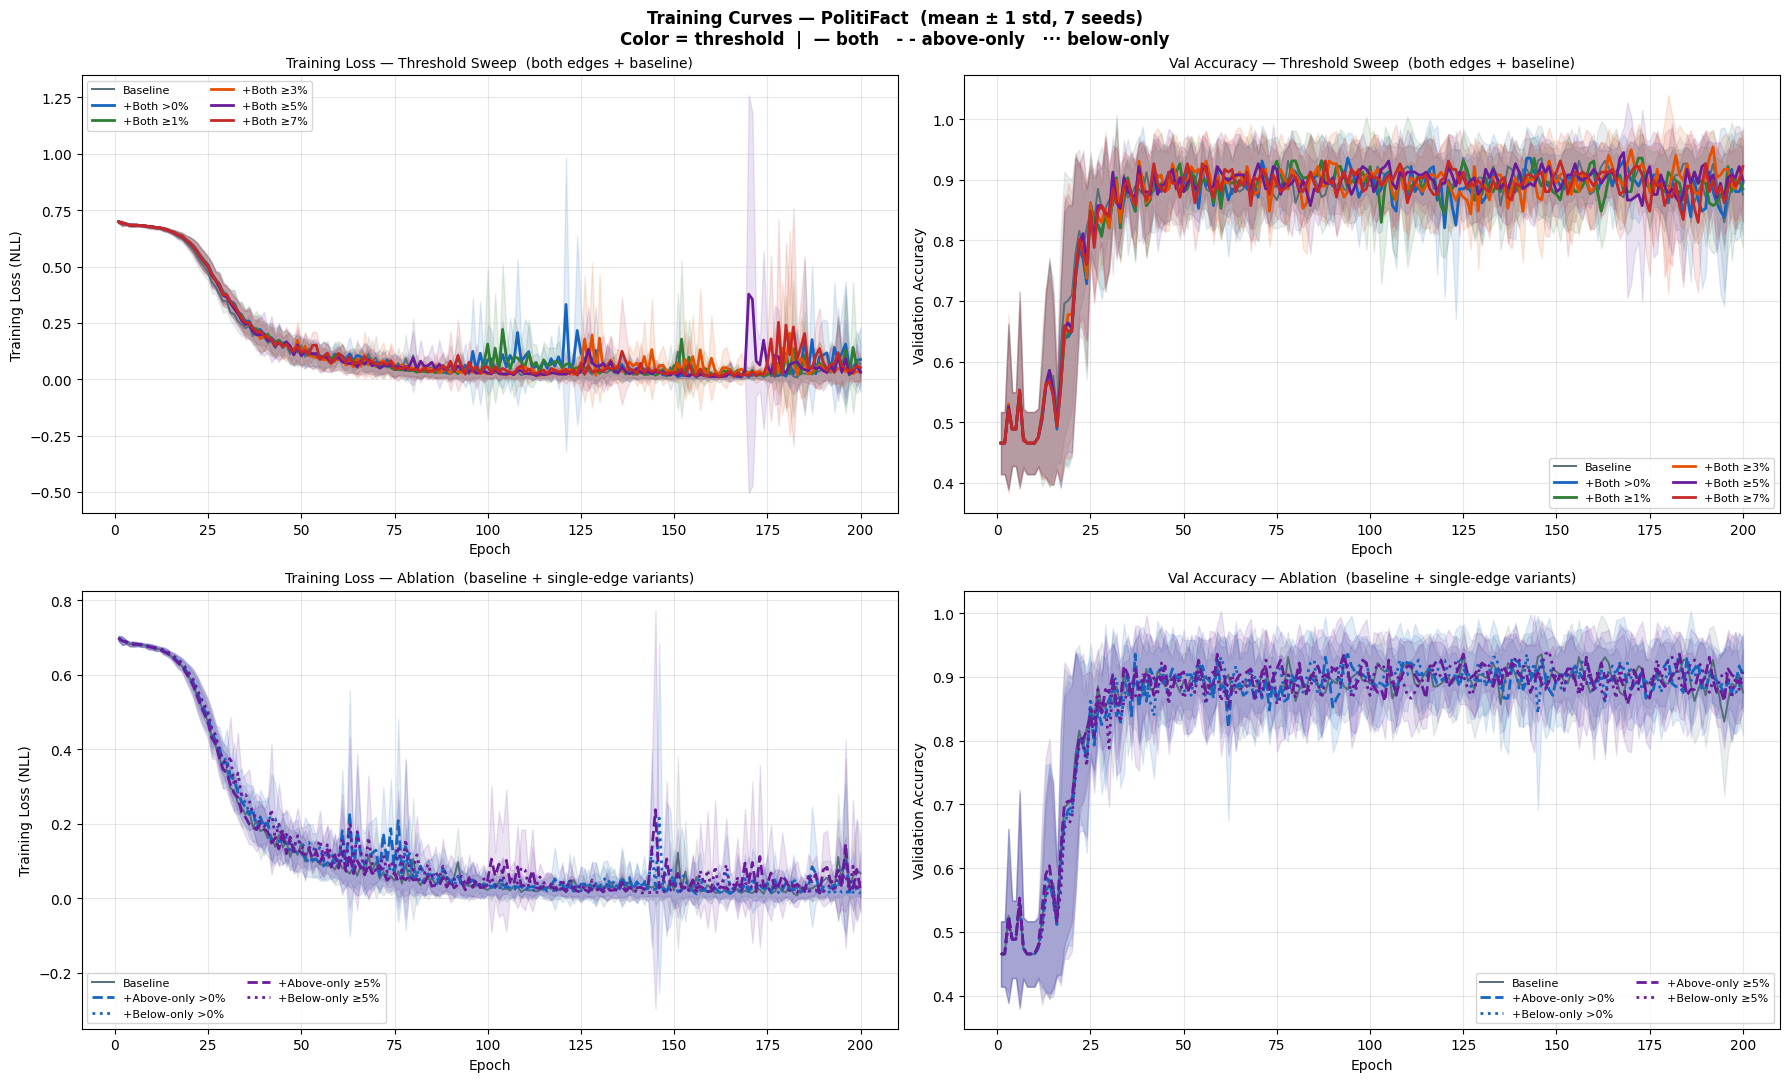

Saved: threshold_sweep_v2_curves.png


In [ ]:
ep = np.arange(1, EPOCHS + 1)

# ── Panel layout: top row = sweep (6 configs), bottom row = ablation (4+baseline) ──
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
fig.suptitle(
    f'Training Curves — PolitiFact  (mean ± 1 std, {len(SEEDS)} seeds)\n'
    f'Color = threshold  |  — both   - - above-only   ··· below-only',
    fontsize=12, fontweight='bold')

ax_loss_sw, ax_val_sw   = axes[0]   # top:    threshold sweep
ax_loss_ab, ax_val_ab   = axes[1]   # bottom: ablation

sweep_cfgs   = [c for c in CONFIGS if c['edge_mode'] in ('none', 'both')]
ablat_cfgs   = [c for c in CONFIGS if c['edge_mode'] in ('none', 'above_only', 'below_only')]

for cfg_group, ax_l, ax_v, title_suffix in [
        (sweep_cfgs, ax_loss_sw, ax_val_sw, 'Threshold Sweep  (both edges + baseline)'),
        (ablat_cfgs, ax_loss_ab, ax_val_ab, 'Ablation  (baseline + single-edge variants)')]:
    for cfg in cfg_group:
        lbl  = cfg['label']
        col  = cfg['color']
        ls   = cfg['ls']
        lw   = 2.0 if cfg['edge_mode'] != 'none' else 1.4
        alpha_fill = 0.12

        ls_m = np.mean(all_results[lbl]['train_losses'], axis=0)
        ls_s = np.std( all_results[lbl]['train_losses'], axis=0)
        va_m = np.mean(all_results[lbl]['val_accs'],     axis=0)
        va_s = np.std( all_results[lbl]['val_accs'],     axis=0)

        ax_l.plot(ep, ls_m, color=col, lw=lw, ls=ls, label=lbl)
        ax_l.fill_between(ep, ls_m - ls_s, ls_m + ls_s, color=col, alpha=alpha_fill)
        ax_v.plot(ep, va_m, color=col, lw=lw, ls=ls, label=lbl)
        ax_v.fill_between(ep, va_m - va_s, va_m + va_s, color=col, alpha=alpha_fill)

    for ax, ylabel, title in [
            (ax_l, 'Training Loss (NLL)', f'Training Loss — {title_suffix}'),
            (ax_v, 'Validation Accuracy', f'Val Accuracy — {title_suffix}')]:
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_sweep_v2_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: threshold_sweep_v2_curves.png')

## Phase 8 — Results Summary

Two tables: threshold sweep (top) and ablation (bottom).  
**Green** = improvement > 0.005 over Baseline. **Red** = regression. **Yellow** = marginal.

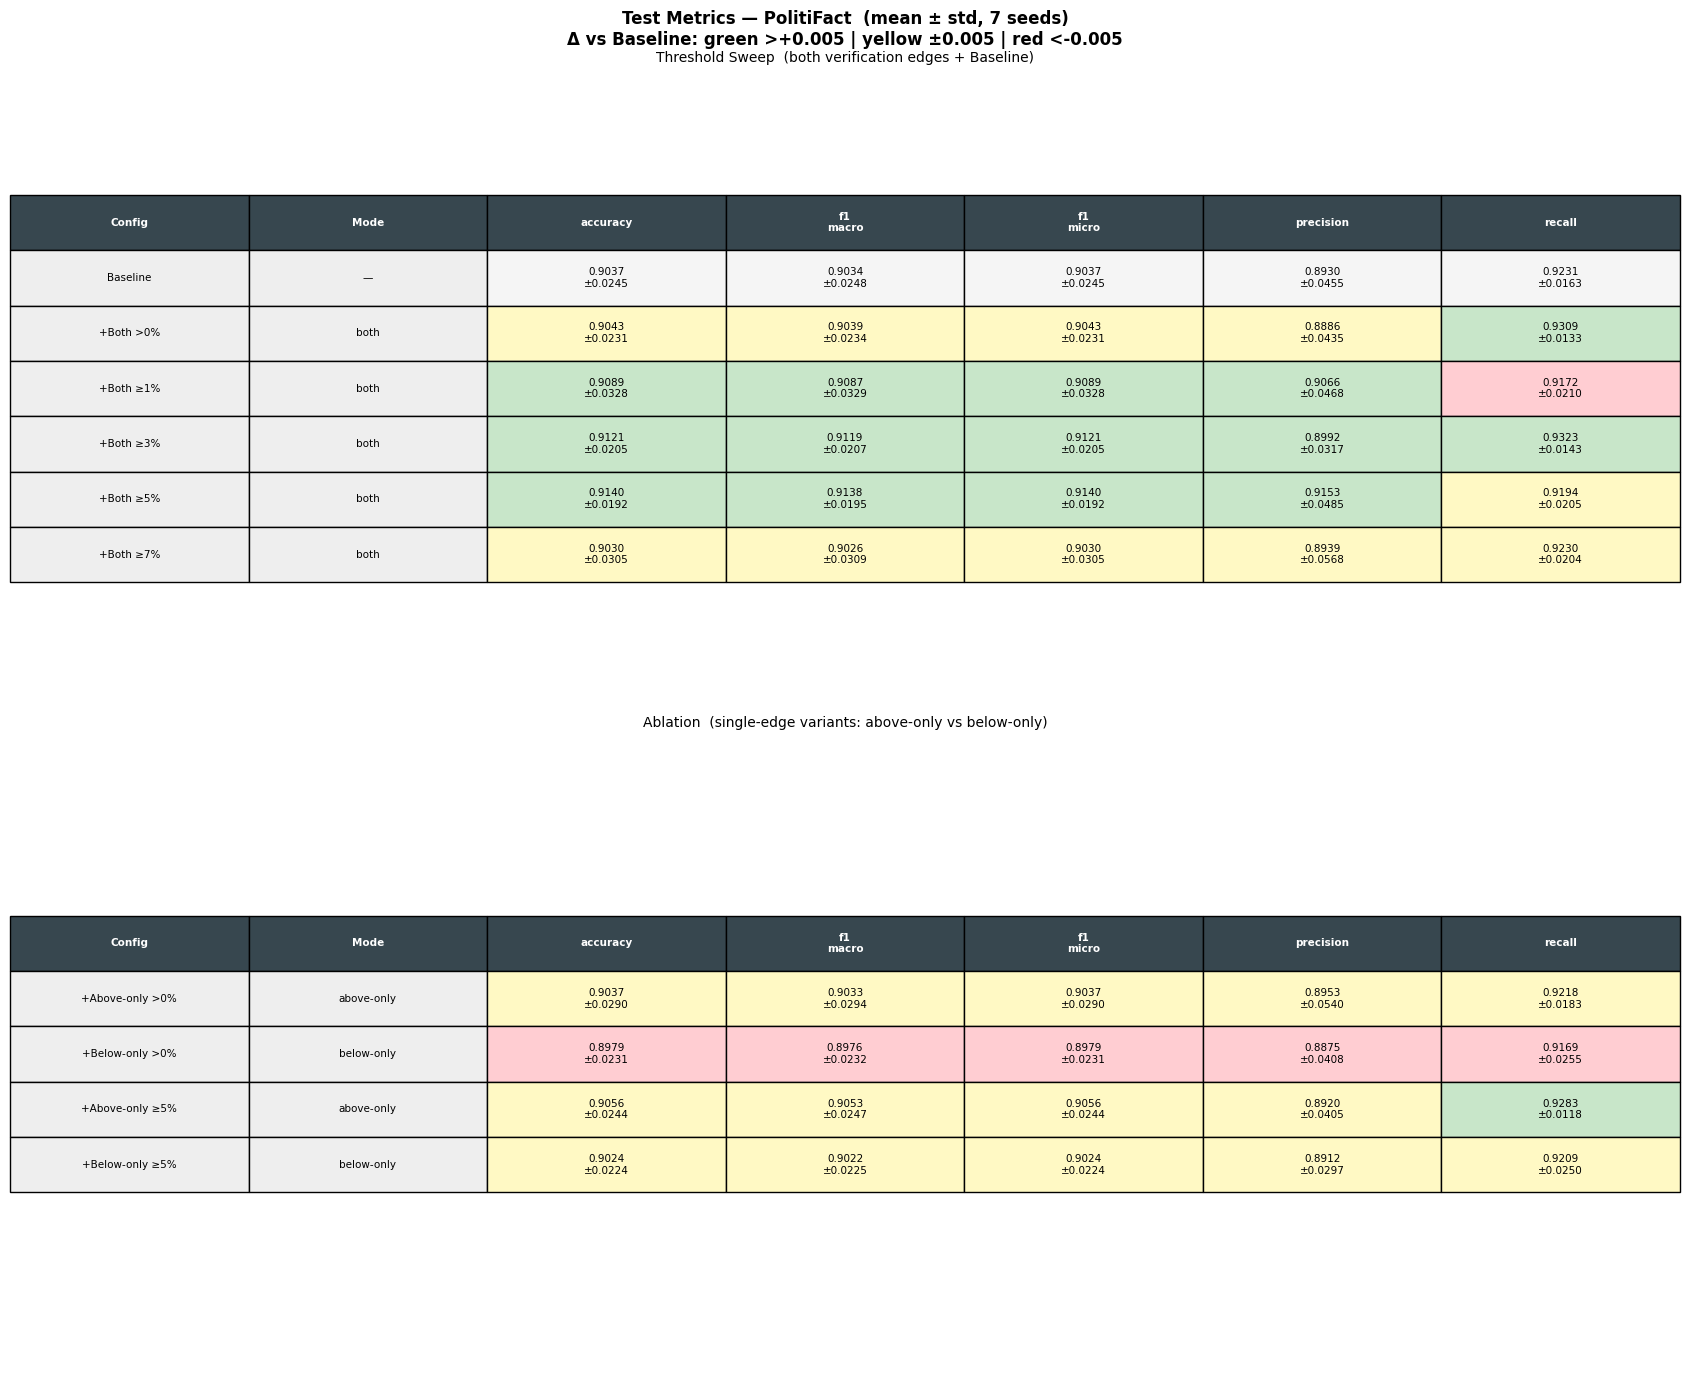

Saved: threshold_sweep_v2_table.png


In [ ]:
METRIC_NAMES = ['accuracy', 'f1_macro', 'f1_micro', 'precision', 'recall']

# ── Aggregate: mean + std per config per metric ───────────────────────────────
summary = {}
for cfg in CONFIGS:
    lbl  = cfg['label']
    vals = {m: [r[m] for r in all_results[lbl]['metrics']] for m in METRIC_NAMES}
    summary[lbl] = {m: (np.mean(vals[m]), np.std(vals[m])) for m in METRIC_NAMES}

baseline_acc = summary['Baseline']['accuracy'][0]


def make_results_table(ax, cfg_group, title):
    """Render a matplotlib table for a subset of configs."""
    col_headers = ['Config', 'Mode'] + [m.replace('_', '\n') for m in METRIC_NAMES]
    table_data, cell_colors = [], []
    for cfg in cfg_group:
        lbl  = cfg['label']
        mode = cfg['edge_mode'].replace('_', '-') if cfg['edge_mode'] != 'none' else '—'
        row        = [lbl, mode]
        row_colors = ['#EEEEEE', '#EEEEEE']
        for m in METRIC_NAMES:
            mu, sd = summary[lbl][m]
            row.append(f'{mu:.4f}\n±{sd:.4f}')
            if lbl == 'Baseline':
                row_colors.append('#F5F5F5')
            else:
                delta = mu - (summary['Baseline'][m][0])
                row_colors.append(
                    '#C8E6C9' if delta >  0.005 else
                    '#FFCDD2' if delta < -0.005 else
                    '#FFF9C4')
        table_data.append(row)
        cell_colors.append(row_colors)

    ax.axis('off')
    tbl = ax.table(cellText=table_data, colLabels=col_headers,
                   cellLoc='center', loc='center', cellColours=cell_colors)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7.5)
    tbl.scale(1.0, 2.6)
    for j in range(len(col_headers)):
        tbl[0, j].set_facecolor('#37474F')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    ax.set_title(title, fontsize=10, pad=10)


sweep_cfgs = [c for c in CONFIGS if c['edge_mode'] in ('none', 'both')]
ablat_cfgs = [c for c in CONFIGS if c['edge_mode'] in ('above_only', 'below_only')]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(17, 14))
fig.suptitle(
    f'Test Metrics — PolitiFact  (mean ± std, {len(SEEDS)} seeds)\n'
    f'Δ vs Baseline: green >+0.005 | yellow ±0.005 | red <-0.005',
    fontsize=12, fontweight='bold')

make_results_table(ax_top, sweep_cfgs,
                   'Threshold Sweep  (both verification edges + Baseline)')
make_results_table(ax_bot, ablat_cfgs,
                   'Ablation  (single-edge variants: above-only vs below-only)')

plt.tight_layout()
plt.savefig('threshold_sweep_v2_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: threshold_sweep_v2_table.png')

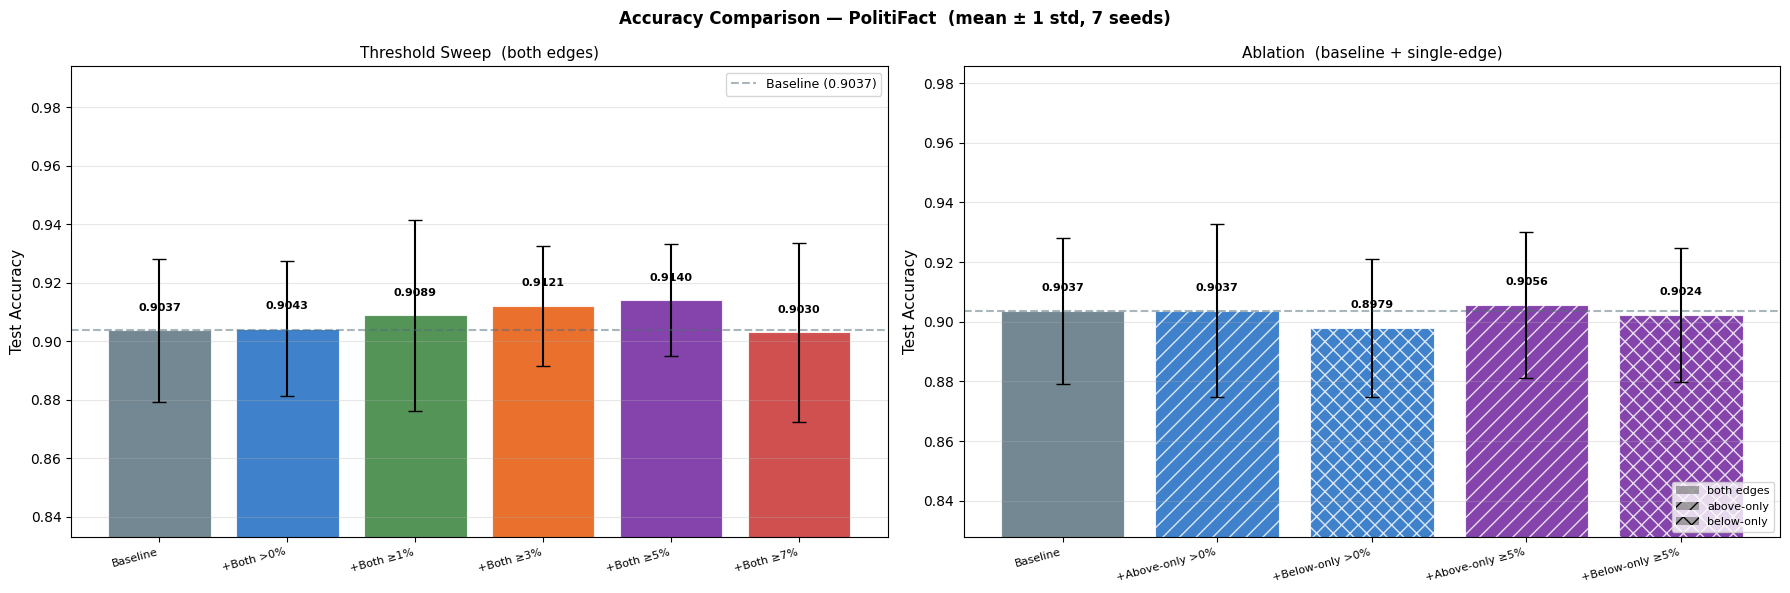

Saved: threshold_sweep_v2_bars.png


In [ ]:
# ── Accuracy bar chart — sweep vs ablation side by side ──────────────────────
fig, (ax_sw, ax_ab) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Accuracy Comparison — PolitiFact  (mean ± 1 std, {len(SEEDS)} seeds)',
             fontsize=12, fontweight='bold')

for ax, cfg_group, title in [
        (ax_sw, [c for c in CONFIGS if c['edge_mode'] in ('none', 'both')],
         'Threshold Sweep  (both edges)'),
        (ax_ab, [c for c in CONFIGS if c['edge_mode'] != 'both'],
         'Ablation  (baseline + single-edge)'),
]:
    labels    = [c['label'] for c in cfg_group]
    means_acc = [summary[c['label']]['accuracy'][0] for c in cfg_group]
    stds_acc  = [summary[c['label']]['accuracy'][1] for c in cfg_group]
    cols_bar  = [c['color'] for c in cfg_group]
    hatches   = ['' if c['edge_mode'] in ('none','both') else
                 '//' if c['edge_mode'] == 'above_only' else 'xx'
                 for c in cfg_group]
    x_pos = np.arange(len(cfg_group))

    bars = ax.bar(x_pos, means_acc, yerr=stds_acc, capsize=5,
                  color=cols_bar, alpha=0.82, edgecolor='white',
                  linewidth=0.8)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    for bar, mu in zip(bars, means_acc):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006,
                f'{mu:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.axhline(baseline_acc, color='#546E7A', linestyle='--', alpha=0.5,
               label=f'Baseline ({baseline_acc:.4f})')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=8, rotation=15, ha='right')
    ax.set_ylabel('Test Accuracy', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(max(0, min(means_acc) - 0.07), min(1, max(means_acc) + 0.08))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

# Hatch legend for ablation panel
legend_handles = [
    mpatches.Patch(facecolor='grey', alpha=0.7, label='both edges'),
    mpatches.Patch(facecolor='grey', alpha=0.7, hatch='//', label='above-only'),
    mpatches.Patch(facecolor='grey', alpha=0.7, hatch='xx', label='below-only'),
]
ax_ab.legend(handles=legend_handles, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('threshold_sweep_v2_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: threshold_sweep_v2_bars.png')

In [ ]:
sep = '=' * 74
print(sep)
print(f'THRESHOLD SWEEP v2 SUMMARY — {DATASET.upper()}')
print(f'Seeds: {SEEDS}   (n={len(SEEDS)})   Epochs: {EPOCHS}')
print(sep)

for group_name, cfg_group in [
    ('THRESHOLD SWEEP  (both edges)', [c for c in CONFIGS if c['edge_mode'] in ('none','both')]),
    ('ABLATION  (single-edge variants)', [c for c in CONFIGS if c['edge_mode'] in ('above_only','below_only')]),
]:
    print(f'\n  {group_name}')
    print(f'  {"Config":<20}  {"accuracy":^20}  {"f1_macro":^20}  {"Δ acc":>8}  {"tag":>12}')
    print(f'  {"-"*20}  {"-"*20}  {"-"*20}  {"-"*8}  {"-"*12}')
    for cfg in cfg_group:
        lbl      = cfg['label']
        mu_acc, sd_acc = summary[lbl]['accuracy']
        mu_f1,  sd_f1  = summary[lbl]['f1_macro']
        delta    = mu_acc - baseline_acc
        tag      = ('IMPROVEMENT' if delta >  0.005 else
                    'REGRESSION'  if delta < -0.005 else 'MARGINAL')
        sign     = '+' if delta >= 0 else ''
        print(f'  {lbl:<20}  {mu_acc:.4f} ± {sd_acc:.4f}    '
              f'{mu_f1:.4f} ± {sd_f1:.4f}    {sign}{delta:.4f}  {tag:>12}')

print(f'\n{sep}')
print('ABLATION KEY QUESTIONS:')
# >0% ablation
both_0  = summary['+Both >0%']['accuracy'][0]
above_0 = summary['+Above-only >0%']['accuracy'][0]
below_0 = summary['+Below-only >0%']['accuracy'][0]
print(f'  At >0%:  both={both_0:.4f}  above-only={above_0:.4f}  below-only={below_0:.4f}')
if below_0 > above_0:
    print('  → "Below" edge (100% fake cluster) carries most signal at >0%')
else:
    print('  → "Above" edge carries signal at >0% (unexpected — investigate)')

# ≥5% ablation
both_5  = summary['+Both ≥5%']['accuracy'][0]
above_5 = summary['+Above-only ≥5%']['accuracy'][0]
below_5 = summary['+Below-only ≥5%']['accuracy'][0]
print(f'  At ≥5%:  both={both_5:.4f}  above-only={above_5:.4f}  below-only={below_5:.4f}')
if above_5 > below_5:
    print('  → "Above" edge (89% real cluster) drives the ≥5% improvement')
elif below_5 > above_5:
    print('  → "Below" edge drives the ≥5% improvement')
else:
    print('  → Both edges contribute roughly equally at ≥5%')
print(sep)

THRESHOLD SWEEP v2 SUMMARY — POLITIFACT
Seeds: [42, 2026, 33, 123, 456, 789, 1000]   (n=7)   Epochs: 200

  THRESHOLD SWEEP  (both edges)
  Config                      accuracy              f1_macro           Δ acc           tag
  --------------------  --------------------  --------------------  --------  ------------
  Baseline              0.9037 ± 0.0245    0.9034 ± 0.0248    +0.0000      MARGINAL
  +Both >0%             0.9043 ± 0.0231    0.9039 ± 0.0234    +0.0006      MARGINAL
  +Both ≥1%             0.9089 ± 0.0328    0.9087 ± 0.0329    +0.0052   IMPROVEMENT
  +Both ≥3%             0.9121 ± 0.0205    0.9119 ± 0.0207    +0.0084   IMPROVEMENT
  +Both ≥5%             0.9140 ± 0.0192    0.9138 ± 0.0195    +0.0103   IMPROVEMENT
  +Both ≥7%             0.9030 ± 0.0305    0.9026 ± 0.0309    -0.0006      MARGINAL

  ABLATION  (single-edge variants)
  Config                      accuracy              f1_macro           Δ acc           tag
  --------------------  --------------------  ---